In [3]:
from qaoa_old import * 
import networkx as nx
import matplotlib.pyplot as plt
from tqdm import tqdm

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def plot_multiple_angles_on_circle(angles_list, alpha=0.1):
    """
    Plot optimal angles as dots on a circle for betas and gammas with different colors for multiple angle arrays.

    Args:
    - angles_list (list of arrays): List of optimal angle arrays for betas and gammas.

    Returns:
    - None
    """
    num_betas = len(angles_list[0]) // 2  # Assuming all arrays have the same length
    num_runs = len(angles_list)
    fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
    ax.set_theta_zero_location('N')
    ax.set_aspect('equal')

    radius = [0.5 + 0.2*i for i in range(num_betas)]
    for angles in angles_list:
        betas = angles[:num_betas]
        gammas = angles[num_betas:]
        for i, r in enumerate(radius):
            # Plot betas with reduced transparency
            ax.plot(betas[i], r, 'bo', markersize=8, alpha=alpha)

            # Plot gammas with reduced transparency
            ax.plot(gammas[i], r, 'ro', markersize=8, alpha=alpha)

    plt.title("Optimal Angles on Circle")
    ax.set_yticks([0.5 + 0.2*i for i in range(num_betas)])
    ax.set_yticklabels([i+1 for i in range(num_betas)])
    plt.show()
    
import numpy as np

def invert(angles):
    if isinstance(angles, list):
        return angles[len(angles)//2:][::-1] + angles[:len(angles)//2][::-1]
    elif isinstance(angles, np.ndarray):
        return np.concatenate((angles[len(angles)//2:][::-1], angles[:len(angles)//2][::-1]))
    else:
        raise ValueError("Unsupported data type. Expected list or ndarray.")

from scipy.optimize import minimize

def make_objective(q):
    def objective(angles):
        return q.expectation(angles)
    return objective

def make_constraint(objective):
    def constraint(angles):
        return objective(angles) - objective(invert(angles))
    return constraint

def optimize_angles(q, initial_angles):
    len_angles = len(initial_angles)
    objective = make_objective(q)
    # Define the optimization problem
    constraint = make_constraint(objective)
    bounds = [(0, np.pi)] * len_angles  # Boundaries from 0 to pi for each angle
    opt_result = minimize(objective, initial_angles, constraints={'type': 'eq', 'fun': constraint}, bounds=bounds)
    
#     return opt_result.x
    if opt_result.success:
        return opt_result.x
    else:
        return []
import numpy as np

def linear_interpolation(theta1, theta2, num_points):
    """
    Perform linear interpolation between two sets of angles.

    Args:
    - theta1 (ndarray): First set of solution angles.
    - theta2 (ndarray): Second set of solution angles.
    - num_points (int): Number of points for interpolation.

    Returns:
    - interpolated_angles (ndarray): Array containing the interpolated angles.
    """
    # Check if the lengths of theta1 and theta2 are the same
    if len(theta1) != len(theta2):
        raise ValueError("Lengths of theta1 and theta2 must be the same.")

    # Linearly interpolate between theta1 and theta2
    interpolated_angles = np.zeros((num_points, len(theta1)))
    for i in range(len(theta1)):
        interpolated_angles[:, i] = np.linspace(theta1[i], theta2[i], num_points)

    return interpolated_angles

def extrapolate_line(theta1, theta2, num_points, extrapolation_factor=0.0):
    """
    Extrapolate the line between two angle vectors beyond the given points.

    Args:
    - theta1 (numpy.ndarray): First angle vector.
    - theta2 (numpy.ndarray): Second angle vector.
    - num_points (int): Number of points to sample along the extended line.
    - extrapolation_factor (float): Factor to determine how far to extrapolate beyond the given points.

    Returns:
    - extrapolated_angles (numpy.ndarray): Array of shape (num_points, n), where n is the dimension of angle vectors.
    """
    direction = theta2 - theta1
    extrapolated_theta1 = theta1 - extrapolation_factor * direction
    extrapolated_theta2 = theta2 + extrapolation_factor * direction
    t = np.linspace(0 - extrapolation_factor, 1 + extrapolation_factor, num_points)[:, None]
    extrapolated_angles = (1 - t) * extrapolated_theta1 + t * extrapolated_theta2
    return extrapolated_angles
# Function to find an approximate orthogonal direction
def find_orthogonal_direction(theta1, theta2):
    diff_vector = np.array(theta2) - np.array(theta1)
    orthogonal_direction = np.random.randn(len(theta1))  # Random vector
    orthogonal_direction -= np.dot(orthogonal_direction, diff_vector) * diff_vector / np.dot(diff_vector, diff_vector)  # Projection
    orthogonal_direction /= np.linalg.norm(orthogonal_direction)  # Normalize
    return orthogonal_direction
def find_direction(theta1, theta2):
    diff_vector = np.array(theta2) - np.array(theta1)
    diff_vector /= np.linalg.norm(diff_vector)  # Normalize
    return diff_vector

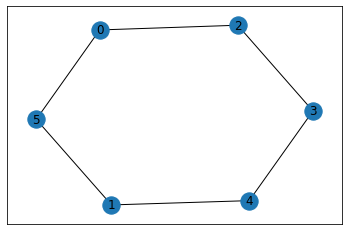

In [7]:
n = 6  # Number of nodes
d = 2  # Degree of each node
G = nx.random_regular_graph(d, n, seed=1)
adj_matrix = nx.adjacency_matrix(G).todense().tolist()
nx.draw_networkx(G)
hamiltonian = Graph_to_Hamiltonian(adj_matrix)

100%|██████████| 100/100 [00:40<00:00,  2.45it/s]


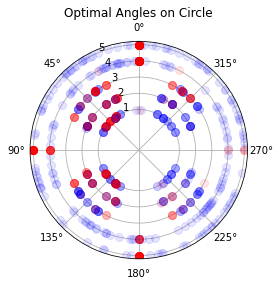

In [8]:
angles_list = []
for i in tqdm(range(100)):
    q = QAOA(5, hamiltonian)
    q.run_heuristic_LW()
    if np.allclose(q.q_error,0):
        angles_list.append(q.opt_angles)
plot_multiple_angles_on_circle(angles_list)


In [10]:
bds = [(0.0, np.pi/2)] * 3 + [(0.0,  np.pi/2)] * 3

100%|██████████| 100/100 [00:26<00:00,  3.79it/s]


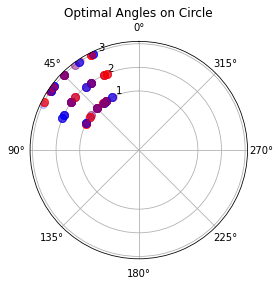

In [11]:
angles_list = []
for i in tqdm(range(100)):
    q = QAOA(3, hamiltonian)
    q.run_heuristic_LW(bds=bds)
    if np.allclose(q.q_error,0):
        angles_list.append(q.opt_angles)
plot_multiple_angles_on_circle(angles_list)


In [33]:
for i in range(10):
    print(angles_list[i] * 8 / np.pi)

[2.80013407 2.42816953 2.49301678 1.50698287 1.57183047 1.19986614]
[1.48661386 1.77499287 1.14099633 2.8590036  2.22500693 2.51338609]
[2.80013413 2.42816953 2.49301676 1.50698291 1.57183049 1.19986607]
[1.19986591 1.57183046 1.5069832  2.49301712 2.42816949 2.80013387]
[1.48661384 1.77499285 1.14099641 2.85900348 2.22500692 2.51338618]
[1.48661376 1.77499602 1.14099689 2.85900042 2.22500404 2.51338542]
[1.62876915 2.88132461 2.36598465 1.63401015 1.11868145 2.37123168]
[1.99999905 0.99999912 2.0000016  2.00000157 2.99999898 2.00000075]
[2.00000089 1.00000035 1.99999976 1.99999755 3.00000078 2.00000038]
[1.4866138  1.77499276 1.1409965  2.85900338 2.225007   2.51338618]


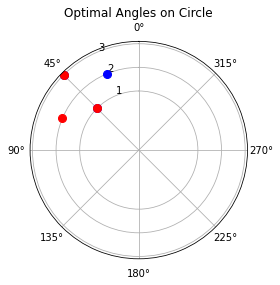

In [29]:
plot_multiple_angles_on_circle([np.array([2,1,2,2,3,2])*np.pi/8], alpha=1)

In [35]:
q.expectation(angles_list[0]), q.expectation(angles_list[1]), q.expectation(angles_list[8])

(-5.999999999999073, -5.9999999999997815, -5.999999999987714)

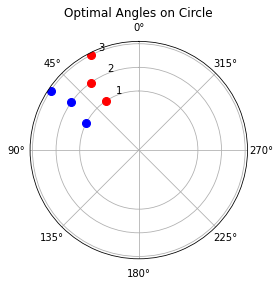

In [36]:
plot_multiple_angles_on_circle([angles_list[0]], alpha=1)

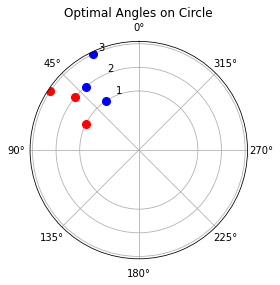

In [37]:
plot_multiple_angles_on_circle([angles_list[1]], alpha=1)

In [43]:
test = angles_list[0]
for i in range(len(test)//2):
    print(test[i] + test[-i-1])

1.570796409046086
1.57079632553097
1.570796190144067


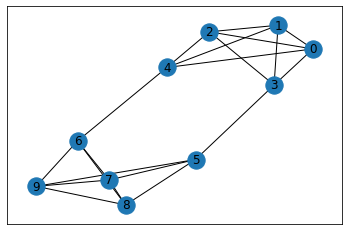

In [44]:
edges = [[0, 1],
 [0, 2],
 [0, 3],
 [0, 4],
 [1, 0],
 [1, 2],
 [1, 3],
 [1, 4],
 [2, 0],
 [2, 1],
 [2, 3],
 [2, 4],
 [3, 0],
 [3, 1],
 [3, 2],
 [3, 5],
 [4, 0],
 [4, 1],
 [4, 2],
 [4, 6],
 [5, 3],
 [5, 7],
 [5, 8],
 [5, 9],
 [6, 4],
 [6, 7],
 [6, 8],
 [6, 9],
 [7, 5],
 [7, 6],
 [7, 8],
 [7, 9],
 [8, 5],
 [8, 6],
 [8, 7],
 [8, 9],
 [9, 5],
 [9, 6],
 [9, 7],
 [9, 8]]
G = nx.from_edgelist(edges)
nx.draw_networkx(G)
adj_matrix = nx.adjacency_matrix(G).todense().tolist()
hamiltonian = Graph_to_Hamiltonian(adj_matrix)

In [49]:
angles_list = []
bds = [(0.0, np.pi/2)] * 9 + [(0.0,  np.pi/2)] * 9
for i in tqdm(range(100)):
    q = QAOA(9, hamiltonian)
    q.run_heuristic_LW(bds=bds)
    if np.allclose(q.q_error,0):
        angles_list.append(q.opt_angles)
plot_multiple_angles_on_circle(angles_list)

100%|██████████| 100/100 [28:18<00:00, 16.99s/it]


IndexError: list index out of range

100%|██████████| 19/19 [00:02<00:00,  7.22it/s]


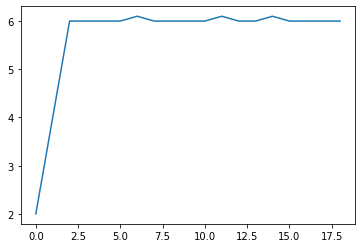

In [9]:
rank = []
for p in tqdm(range(1,20)):
    q = QAOA(p, hamiltonian)
    buf = 0
    for _ in range(10):
        buf += np.linalg.matrix_rank(q.qaoa_qfi_matrix(np.random.rand(2*p)*np.pi))
    rank.append(buf/10)
plt.plot(rank)

100%|██████████| 100/100 [00:51<00:00,  1.92it/s]


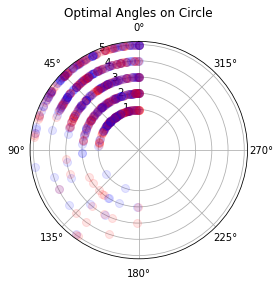

In [10]:
sym_angles = []
for i in tqdm(range(100)):
    initial_angles = np.random.rand(10)  # Example initial angles
    optimized_angles = optimize_angles(q, initial_angles)
    if len(optimized_angles) != 0:
        sym_angles.append(optimized_angles)
plot_multiple_angles_on_circle(sym_angles)

In [11]:
q.expectation(invert(sym_angles[1])), q.expectation(sym_angles[1])

(-5.999989603475629, -5.999989603475622)

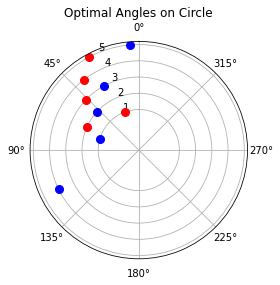

In [12]:
plot_multiple_angles_on_circle([sym_angles[0]],alpha=1)

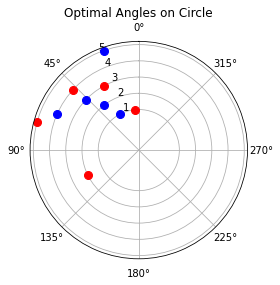

In [13]:
plot_multiple_angles_on_circle([ invert(sym_angles[0])],alpha=1)

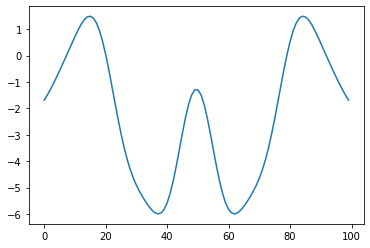

In [44]:
ang_id = 10
theta1 = sym_angles[ang_id]  # First set of solution angles
theta2 = invert(sym_angles[ang_id])  # Second set of solution angles
num_points = 100  # Number of points for interpolation

interpolated_angles = extrapolate_line(theta1, theta2, num_points,0.5)
landscape = []
for i in interpolated_angles:
    landscape.append(q.expectation(i))
plt.plot(landscape)

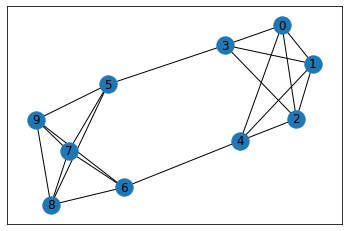

In [45]:
edges = [[0, 1],
 [0, 2],
 [0, 3],
 [0, 4],
 [1, 0],
 [1, 2],
 [1, 3],
 [1, 4],
 [2, 0],
 [2, 1],
 [2, 3],
 [2, 4],
 [3, 0],
 [3, 1],
 [3, 2],
 [3, 5],
 [4, 0],
 [4, 1],
 [4, 2],
 [4, 6],
 [5, 3],
 [5, 7],
 [5, 8],
 [5, 9],
 [6, 4],
 [6, 7],
 [6, 8],
 [6, 9],
 [7, 5],
 [7, 6],
 [7, 8],
 [7, 9],
 [8, 5],
 [8, 6],
 [8, 7],
 [8, 9],
 [9, 5],
 [9, 6],
 [9, 7],
 [9, 8]]

G = nx.from_edgelist(edges)
nx.draw_networkx(G)
adj_matrix = nx.adjacency_matrix(G).todense().tolist()
hamiltonian = Graph_to_Hamiltonian(adj_matrix)

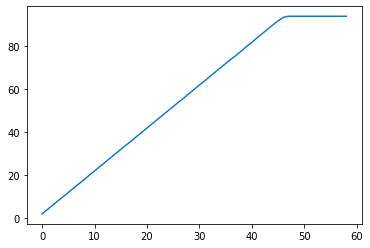

In [56]:
rank = []
for p in range(1,60):
    q = QAOA(p, hamiltonian)
    buf = 0
    for _ in range(10):
        buf += np.linalg.matrix_rank(q.qaoa_qfi_matrix(np.random.rand(2*p)*np.pi))
    rank.append(buf/10)
plt.plot(rank)

100%|██████████| 100/100 [33:47<00:00, 20.27s/it]


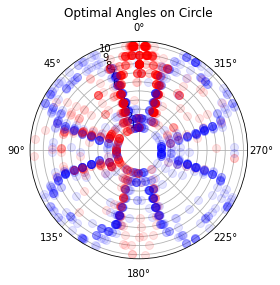

In [57]:
angles_list = []
for i in tqdm(range(100)):
    q = QAOA(10, hamiltonian)
    q.run_heuristic_LW()
    if q.q_error < 0.1:
        angles_list.append(q.opt_angles)
plot_multiple_angles_on_circle(angles_list)


100%|██████████| 100/100 [03:35<00:00,  2.16s/it]


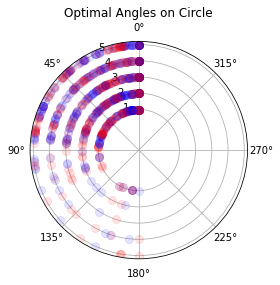

In [58]:
sym_angles = []
for i in tqdm(range(100)):
    initial_angles = np.random.rand(10)  # Example initial angles
    optimized_angles = optimize_angles(q, initial_angles)
    if len(optimized_angles) != 0:
        sym_angles.append(optimized_angles)
plot_multiple_angles_on_circle(sym_angles)

In [49]:
q = QAOA(10, hamiltonian)
q.run_heuristic_LW()
just_angles = q.opt_angles 
initial_angles = np.random.rand(10)  # Example initial angles
symm_angles = optimize_angles(q, initial_angles)
optim_angles = np.array([2,5,6,6,6,6,5,2])*np.pi/8

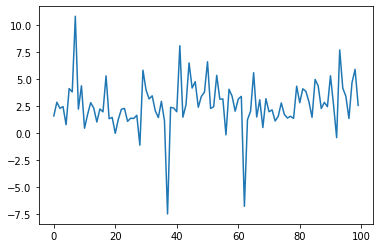

In [50]:
theta1 = just_angles  # First set of solution angles
theta2 = invert(just_angles)  # Second set of solution angles
num_points = 100  # Number of points for interpolation

interpolated_angles = extrapolate_line(theta1, theta2, num_points,0.5)
landscape = []
for i in interpolated_angles:
    landscape.append(q.expectation(i))
plt.plot(landscape)

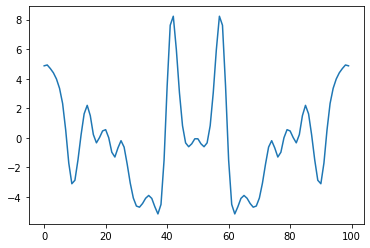

In [70]:
theta1 = symm_angles  # First set of solution angles
theta2 = invert(symm_angles)  # Second set of solution angles
num_points = 100  # Number of points for interpolation

interpolated_angles = extrapolate_line(theta1, theta2, num_points,0.5)
landscape = []
for i in interpolated_angles:
    landscape.append(q.expectation(i))
plt.plot(landscape)

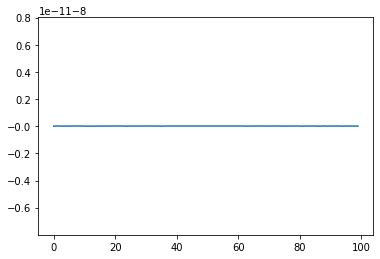

In [53]:
theta1 = optim_angles  # First set of solution angles
theta2 = invert(optim_angles)  # Second set of solution angles
num_points = 100  # Number of points for interpolation

interpolated_angles = extrapolate_line(theta1, theta2, num_points,1.5)
landscape = []
for i in interpolated_angles:
    landscape.append(q.expectation(i))
plt.plot(landscape)

In [91]:
import numpy as np
import matplotlib.pyplot as plt

theta1 = symm_angles  # First set of solution angles
theta2 = invert(symm_angles)  # Second set of solution angles


num_points = 100  # Number of points for interpolation

# Extrapolate points
interpolated_points = extrapolate_line(theta1, theta2, num_points, .5)

# Find approximate orthogonal direction
orthogonal_direction = find_orthogonal_direction(theta1, theta2)


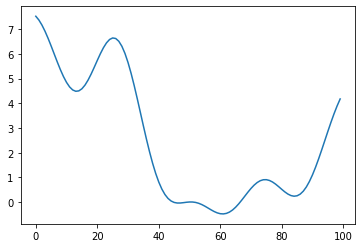

In [99]:
orthogonal_direction = find_orthogonal_direction(theta1, theta2)
testing = [q.expectation((theta1 + theta2) + t * orthogonal_direction) for t in np.linspace(-1,1,100)]
plt.plot(testing)

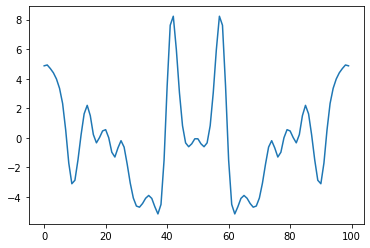

In [93]:
plt.plot([q.expectation(i) for i in interpolated_points])

In [112]:
orthogonal_direction = find_orthogonal_direction(theta1, theta2)
direction = find_direction(theta1, theta2)

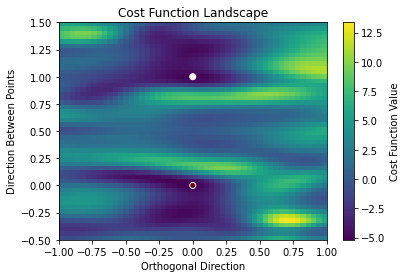

In [113]:
# Evaluate cost function on a 2D grid
grid_size = 50
cost_grid = np.zeros((grid_size, grid_size))
for i, alpha in enumerate(np.linspace(-0.5, 1.5, grid_size)):
    for j, beta in enumerate(np.linspace(-1., 1., grid_size)):
        combined_direction = theta1 + direction * np.linalg.norm(theta1-theta2) * alpha + orthogonal_direction * beta
        cost_grid[i, j] = q.expectation(combined_direction)

# Plot the cost function landscape
plt.imshow(cost_grid, extent=[-1., 1., -0.5, 1.5], origin='lower', aspect='auto', cmap='viridis')
plt.colorbar(label='Cost Function Value')


# Evaluate cost function at theta1 and theta2
cost_theta1 = q.expectation(theta1)
cost_theta2 = q.expectation(theta2)
# Plot points for theta1 and theta2
plt.scatter([0, 0], [0, 1], c=[cost_theta1, cost_theta2], cmap='Reds', label='Theta1/Theta2', edgecolors='w', zorder=5)

plt.xlabel('Orthogonal Direction')
plt.ylabel('Direction Between Points')
plt.title('Cost Function Landscape')
plt.show()
plt.show()

